In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Всички библиотеки заредени успешно!")

✅ Всички библиотеки заредени успешно!


In [35]:
TENSORS_DIR = r"D:\Магистър\Общ проект\ADNI_tensors_complete"
CSV_PATH = r"D:\Магистър\Общ проект\adni_search_results.txt"

# Проверяваме дали пътищата съществуват преди да продължим
assert os.path.isdir(TENSORS_DIR), f"❌ Папката не е намерена: {TENSORS_DIR}"
assert os.path.isfile(CSV_PATH),   f"❌ CSV файлът не е намерен: {CSV_PATH}"

all_files = os.listdir(TENSORS_DIR)
mri_files = sorted([f for f in all_files if f.endswith("_mri.npy")])
pet_files  = sorted([f for f in all_files if f.endswith("_pet.npy")])

print(f"✅ MRI файлове намерени: {len(mri_files)}")
print(f"✅ PET файлове намерени:  {len(pet_files)}")
print(f"   Общо файлове в папката: {len(all_files)}")
print()
print("Първите 5 MRI файла:")
for f in mri_files[:5]:
    print(f"  {f}")

✅ MRI файлове намерени: 458
✅ PET файлове намерени:  458
   Общо файлове в папката: 918

Първите 5 MRI файла:
  002_S_0295_mri.npy
  002_S_0413_mri.npy
  002_S_0685_mri.npy
  002_S_1261_mri.npy
  002_S_1280_mri.npy


In [36]:
def get_subject_id(filename):
    """
    '002_S_0295_mri.npy'  ->  '002_S_0295'
    Премахваме последната част (_mri или _pet) и разширението.
    """
    name = filename.replace("_mri.npy", "").replace("_pet.npy", "")
    return name

# Тест
print(get_subject_id("002_S_0295_mri.npy"))  # -> 002_S_0295
print(get_subject_id("003_S_0907_pet.npy"))  # -> 003_S_0907

# Извличаме всички уникални subject ID-та от файловете
available_subjects = set(get_subject_id(f) for f in mri_files)
print(f"\nУникални субекти с MRI данни: {len(available_subjects)}")

002_S_0295
003_S_0907

Уникални субекти с MRI данни: 458


In [38]:
print("Разпределение на всички групи:")
print(df_all["Research Group"].value_counts())
print()

# Запазваме само AD и CN
df = df_all[df_all["Research Group"].isin(["AD", "CN"])].copy()

# Създаваме числов label: CN = 0, AD = 1
df["label"] = df["Research Group"].map({
    "CN": 0,
    "AD": 1
})

# Нормализираме Subject ID като текст
df["Subject ID"] = df["Subject ID"].astype(str).str.strip()

print("--- След филтриране само AD и CN ---")
print(f"AD (Alzheimer's Disease): {(df['Research Group'] == 'AD').sum()}")
print(f"CN (Cognitively Normal): {(df['Research Group'] == 'CN').sum()}")
print(f"Общо записи: {len(df)}")

display(df.head(8))

Разпределение на всички групи:
Research Group
CN    35452
AD    10932
Name: count, dtype: int64

--- След филтриране само AD и CN ---
AD (Alzheimer's Disease): 10932
CN (Cognitively Normal): 35452
Общо записи: 46384


,Subject ID,Phase,Sex,Weight,Research Group,APOE A1,APOE A2,Visit,Study Date,Archive Date,...,Description,Type,Imaging Protocol,Image ID,Structure,Laterality,Image Type,Registration,Tissue,label
0,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR-R; GradWarp; B1 Correction; N3 <- MP-RAGE ...,Pre-processed,NaN,45112,Brain,Both,image volume,native,All,0
1,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR-R; GradWarp; B1 Correction <- MP-RAGE REPEAT,Pre-processed,NaN,45113,Brain,Both,image volume,native,All,0
2,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR-R; GradWarp <- MP-RAGE REPEAT,Pre-processed,NaN,45114,Brain,Both,image volume,native,All,0
3,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR; GradWarp; B1 Correction; N3 <- MP-RAGE,Pre-processed,NaN,45107,Brain,Both,image volume,native,All,0
4,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR; GradWarp; B1 Correction; N3; Scaled <- MP...,Pre-processed,NaN,45108,Brain,Both,image volume,native,All,0
5,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR; GradWarp; B1 Correction <- MP-RAGE,Pre-processed,NaN,45109,Brain,Both,image volume,native,All,0
6,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,3/19/2007,...,MPR; GradWarp <- MP-RAGE,Pre-processed,NaN,45110,Brain,Both,image volume,native,All,0
7,002_S_0295,ADNI 1,M,74.5,CN,3.0,4.0,ADNI Screening,4/18/2006,8/28/2013,...,HHP 6 DOF AC-PC registered MPRAGE <- MP-RAGE,Pre-processed,NaN,387726,Brain,Both,image volume,MNI152,All,0


In [39]:
labels_df = df[["Subject ID", "Research Group", "label"]].drop_duplicates(
    subset=["Subject ID"]
).copy()

labels_df = labels_df.rename(columns={
    "Subject ID": "subject_id",
    "Research Group": "diagnosis"
})

print("Уникални субекти с AD/CN label:", len(labels_df))
print(labels_df["diagnosis"].value_counts())

display(labels_df.head())

Уникални субекти с AD/CN label: 1387
diagnosis
CN    1029
AD     358
Name: count, dtype: int64


,subject_id,diagnosis,label
0,002_S_0295,CN,0
71,002_S_0413,CN,0
205,002_S_0685,CN,0
291,002_S_1261,CN,0
418,002_S_1280,CN,0


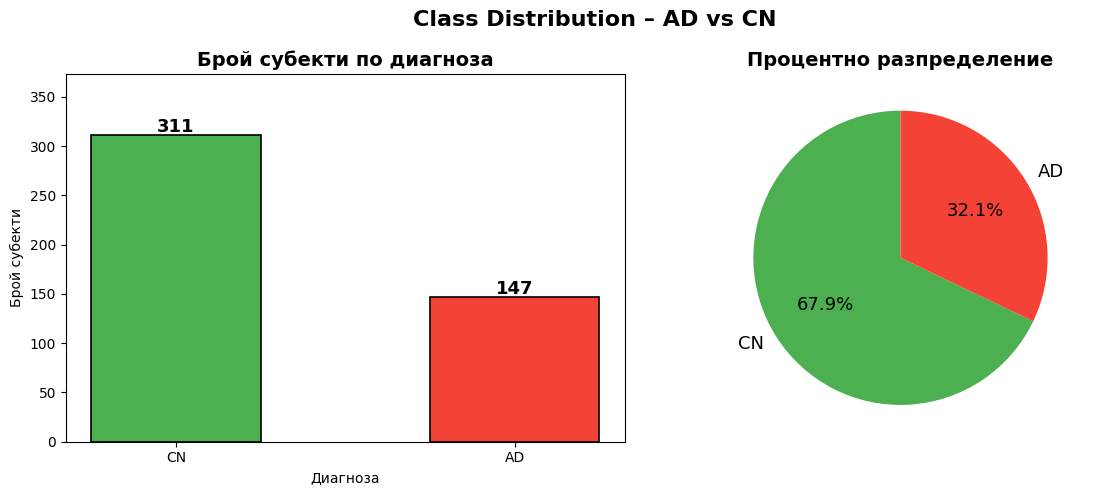

💾 Запазено: class_distribution.png


In [42]:
import matplotlib.pyplot as plt

# Броим класовете от финалния dataset
counts = dataset_df["diagnosis"].value_counts()

# Подреждаме, за да е винаги CN първо, AD второ
counts = counts.reindex(["CN", "AD"])

colors = ["#4CAF50", "#F44336"]  # зелено = CN, червено = AD

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(
    counts.index,
    counts.values,
    color=colors,
    width=0.5,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title("Брой субекти по диагноза", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Брой субекти")
axes[0].set_xlabel("Диагноза")
axes[0].set_ylim(0, max(counts.values) * 1.2)

for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 3,
        str(val),
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    textprops={"fontsize": 13}
)

axes[1].set_title("Процентно разпределение", fontsize=14, fontweight="bold")

plt.suptitle("Class Distribution – AD vs CN", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("💾 Запазено: class_distribution.png")

AD субекти за визуализация:
['002_S_5018', '003_S_4136']
CN субекти за визуализация:
['002_S_0295', '002_S_0413']


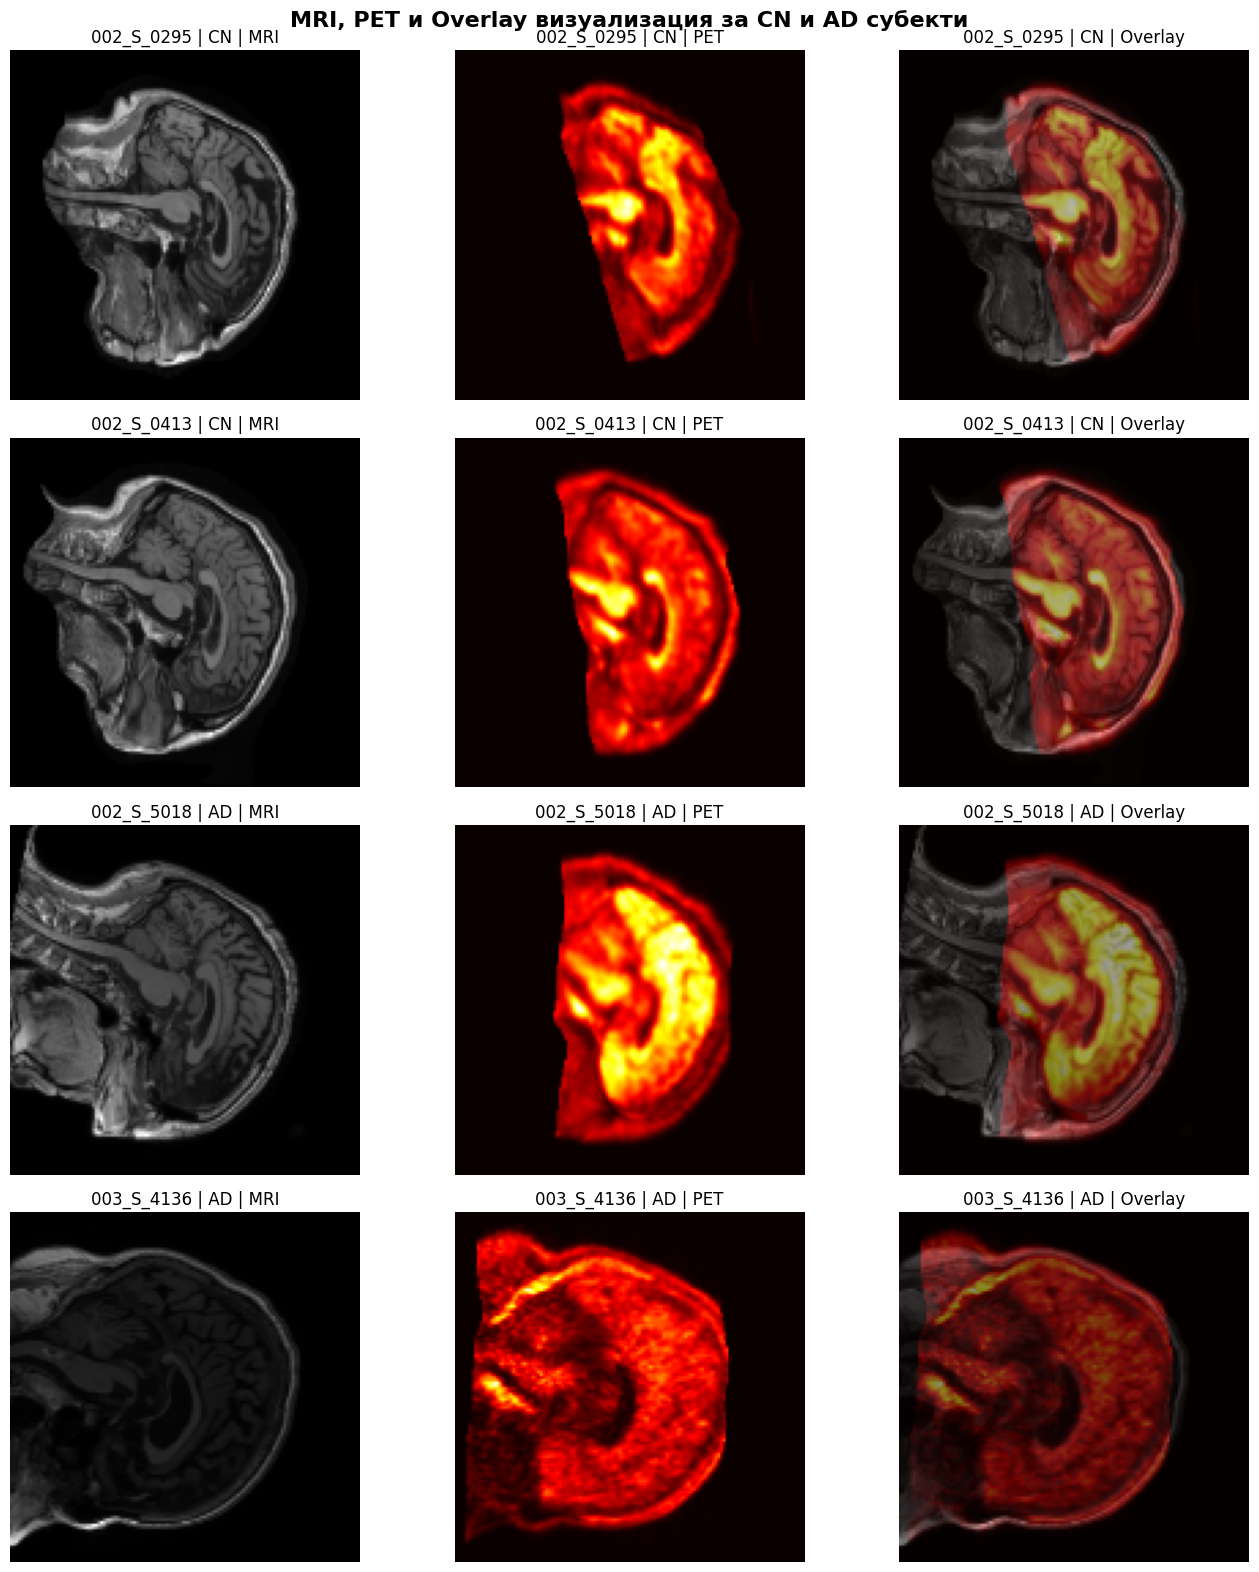

💾 Запазено: brain_scans_by_diagnosis.png


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import os

def load_pair(row):
    """
    Зарежда MRI и PET тензорите за даден ред от dataset_df.
    """
    mri = np.load(row["mri_path"])
    pet = np.load(row["pet_path"])
    return mri, pet


# Намираме по 2 субекта от всяка група
ad_rows = dataset_df[dataset_df["diagnosis"] == "AD"].head(2)
cn_rows = dataset_df[dataset_df["diagnosis"] == "CN"].head(2)

print("AD субекти за визуализация:")
print(ad_rows["subject_id"].tolist())

print("CN субекти за визуализация:")
print(cn_rows["subject_id"].tolist())


# Обединяваме ги в една таблица за визуализация
sample_df = pd.concat([cn_rows, ad_rows], ignore_index=True)

SLICE = 64  # среден аксиален слой от 128

fig, axes = plt.subplots(len(sample_df), 3, figsize=(14, 4 * len(sample_df)))

for row_idx, row in sample_df.iterrows():
    mri, pet = load_pair(row)

    subject_id = row["subject_id"]
    diagnosis = row["diagnosis"]

    # MRI
    axes[row_idx, 0].imshow(mri[SLICE], cmap="gray")
    axes[row_idx, 0].set_title(f"{subject_id} | {diagnosis} | MRI")
    axes[row_idx, 0].axis("off")

    # PET
    axes[row_idx, 1].imshow(pet[SLICE], cmap="hot")
    axes[row_idx, 1].set_title(f"{subject_id} | {diagnosis} | PET")
    axes[row_idx, 1].axis("off")

    # Overlay MRI + PET
    axes[row_idx, 2].imshow(mri[SLICE], cmap="gray")
    axes[row_idx, 2].imshow(pet[SLICE], cmap="hot", alpha=0.45)
    axes[row_idx, 2].set_title(f"{subject_id} | {diagnosis} | Overlay")
    axes[row_idx, 2].axis("off")

plt.suptitle("MRI, PET и Overlay визуализация за CN и AD субекти", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.savefig("brain_scans_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

print("💾 Запазено: brain_scans_by_diagnosis.png")

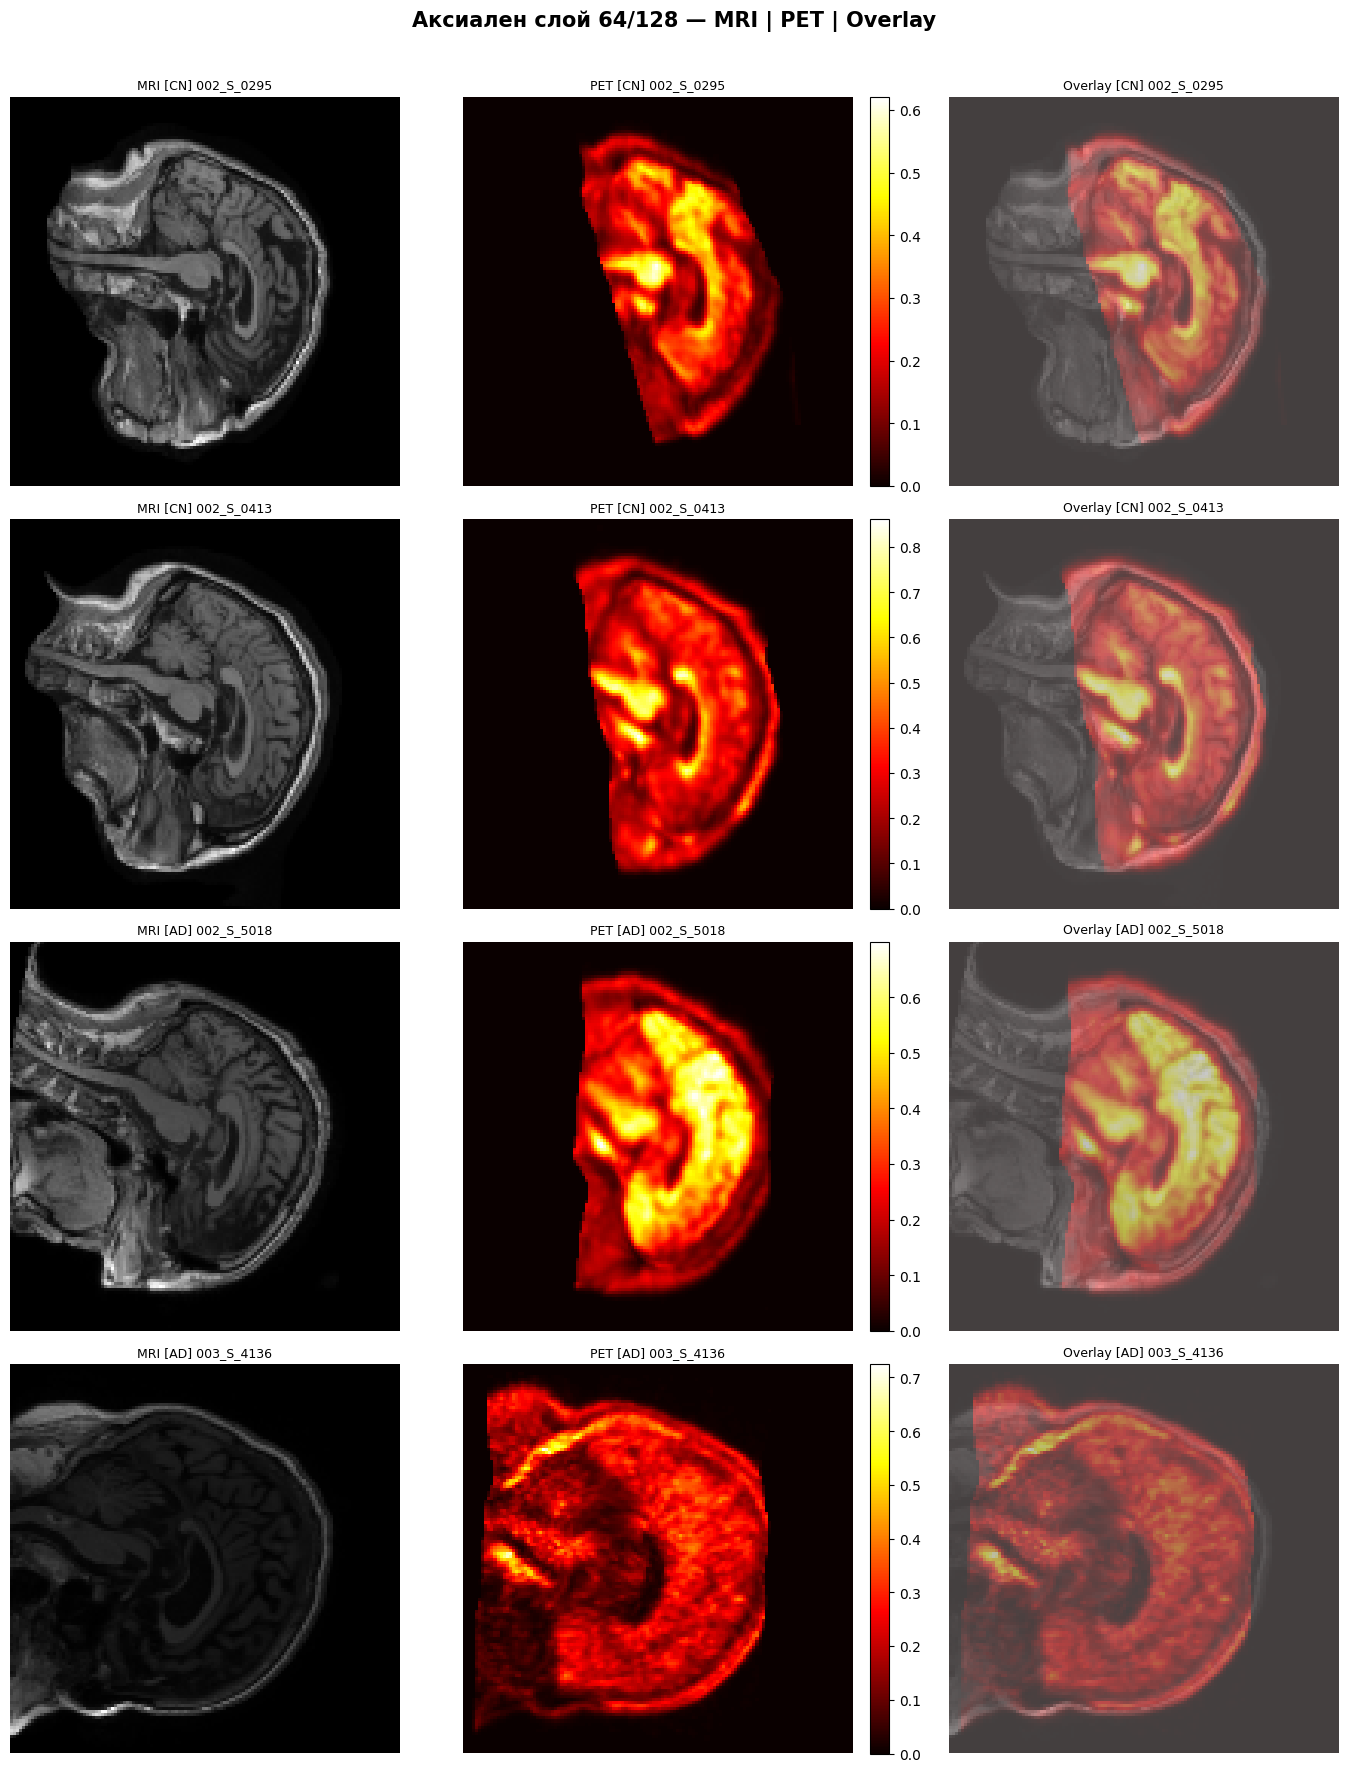

💾 Запазено: brain_scans_comparison.png


In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Функция за зареждане на MRI и PET за даден subject_id
def load_pair(tensors_dir, subject_id):
    mri = np.load(os.path.join(tensors_dir, f"{subject_id}_mri.npy"))
    pet = np.load(os.path.join(tensors_dir, f"{subject_id}_pet.npy"))
    return mri, pet

# Вземаме по 2 субекта от всяка група от финалния dataset
cn_subj = dataset_df.loc[dataset_df["diagnosis"] == "CN", "subject_id"].head(2).tolist()
ad_subj = dataset_df.loc[dataset_df["diagnosis"] == "AD", "subject_id"].head(2).tolist()

# Проверка дали има достатъчно субекти
if len(cn_subj) < 2 or len(ad_subj) < 2:
    raise ValueError("Няма достатъчно субекти за визуализация.")

sample = [
    ("CN", cn_subj[0]),
    ("CN", cn_subj[1]),
    ("AD", ad_subj[0]),
    ("AD", ad_subj[1])
]

SLICE = 64  # среден аксиален слой

fig, axes = plt.subplots(4, 3, figsize=(14, 18))

for row, (group, subj) in enumerate(sample):
    mri, pet = load_pair(TENSORS_DIR, subj)

    # Колона 0: MRI
    axes[row, 0].imshow(mri[SLICE], cmap="gray")
    axes[row, 0].set_title(f"MRI [{group}] {subj}", fontsize=9)
    axes[row, 0].axis("off")

    # Колона 1: PET
    im = axes[row, 1].imshow(pet[SLICE], cmap="hot")
    axes[row, 1].set_title(f"PET [{group}] {subj}", fontsize=9)
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

    # Колона 2: Overlay
    axes[row, 2].imshow(mri[SLICE], cmap="gray", alpha=0.55)
    axes[row, 2].imshow(pet[SLICE], cmap="hot", alpha=0.45)
    axes[row, 2].set_title(f"Overlay [{group}] {subj}", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle(
    f"Аксиален слой {SLICE}/128 — MRI | PET | Overlay",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("brain_scans_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("💾 Запазено: brain_scans_comparison.png")

In [46]:
import numpy as np
import pandas as pd

records = []

for _, row in dataset_df.iterrows():
    subj = row["subject_id"]
    group = row["diagnosis"]

    mri_path = row["mri_path"]
    pet_path = row["pet_path"]

    mri = np.load(mri_path)
    pet = np.load(pet_path)

    records.append({
        "subject_id": subj,
        "diagnosis": group,
        "label": row["label"],

        "mri_mean": round(float(mri.mean()), 4),
        "mri_std":  round(float(mri.std()),  4),
        "mri_min":  round(float(mri.min()),  4),
        "mri_max":  round(float(mri.max()),  4),

        "pet_mean": round(float(pet.mean()), 4),
        "pet_std":  round(float(pet.std()),  4),
        "pet_min":  round(float(pet.min()),  4),
        "pet_max":  round(float(pet.max()),  4),
    })

stats_df = pd.DataFrame(records)

print(f"✅ Статистики изчислени за {len(stats_df)} субекта")
print()

print("Средни стойности по диагноза:")
display(
    stats_df
    .groupby("diagnosis")[["mri_mean", "mri_std", "pet_mean", "pet_std"]]
    .mean()
    .round(4)
)

✅ Статистики изчислени за 458 субекта

Средни стойности по диагноза:


,mri_mean,mri_std,pet_mean,pet_std
diagnosis,,,,
AD,0.0747,0.1215,0.0809,0.1428
CN,0.0790,0.1301,0.0681,0.1233


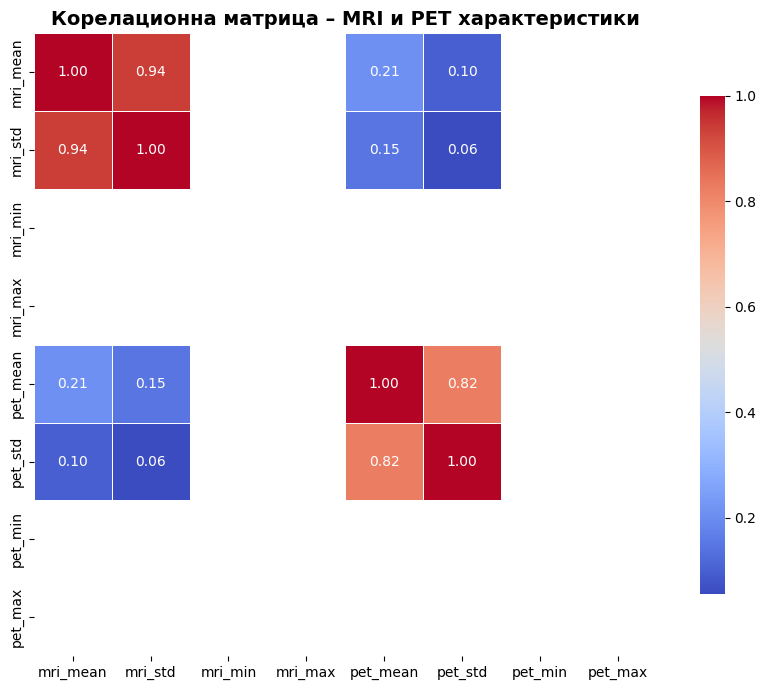

💾 Запазено: correlation_heatmap.png


In [47]:
numeric_cols = ["mri_mean", "mri_std", "mri_min", "mri_max",
                "pet_mean", "pet_std", "pet_min", "pet_max"]

corr = stats_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Корелационна матрица – MRI и PET характеристики",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Запазено: correlation_heatmap.png")

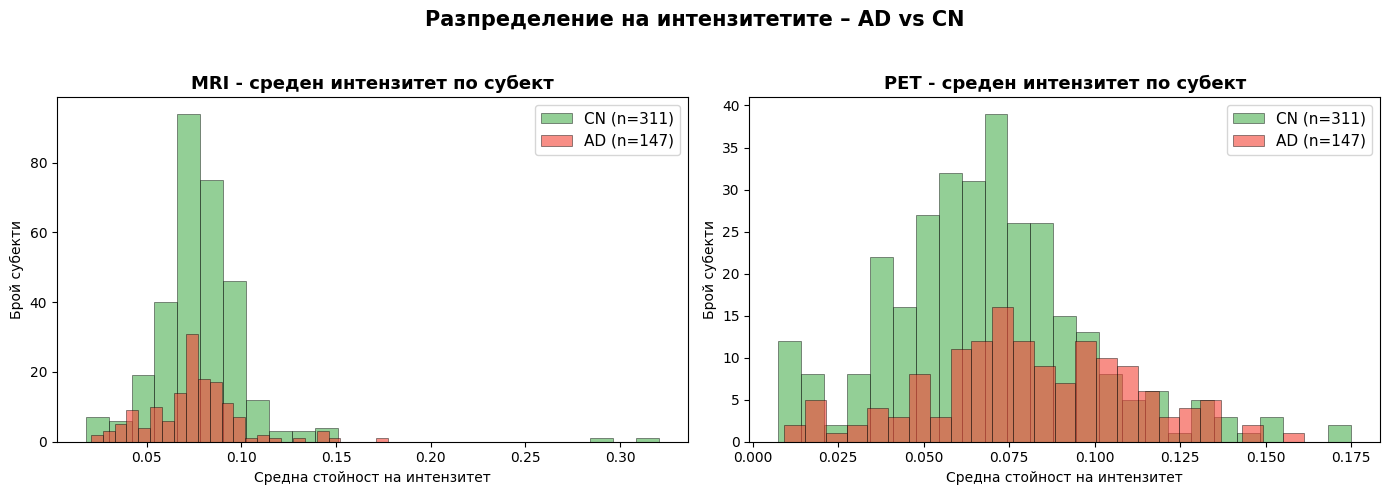

💾 Запазено: intensity_distribution.png


In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["mri_mean", "pet_mean"],
    ["MRI - среден интензитет по субект", "PET - среден интензитет по субект"]
):
    for group, color in [("CN", "#4CAF50"), ("AD", "#F44336")]:
        vals = stats_df.loc[stats_df["diagnosis"] == group, col]

        ax.hist(
            vals,
            bins=25,
            alpha=0.6,
            color=color,
            label=f"{group} (n={len(vals)})",
            edgecolor="black",
            linewidth=0.5
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Средна стойност на интензитет")
    ax.set_ylabel("Брой субекти")
    ax.legend(fontsize=11)

plt.suptitle(
    "Разпределение на интензитетите – AD vs CN",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("intensity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("💾 Запазено: intensity_distribution.png")

In [51]:
import os
import numpy as np

print("=" * 55)
print("  QUALITY CHECK НА ДАННИТЕ")
print("=" * 55)

missing_files = []
wrong_shape = []
wrong_range = []
nan_values = []
valid_subjects = []

expected_shape = (128, 128, 128)

for _, row in dataset_df.iterrows():
    subj = row["subject_id"]

    mri_path = row["mri_path"]
    pet_path = row["pet_path"]

    # 1. Проверка дали файловете съществуват
    if not os.path.exists(mri_path) or not os.path.exists(pet_path):
        missing_files.append(subj)
        continue

    mri = np.load(mri_path)
    pet = np.load(pet_path)

    # 2. Проверка за форма
    if mri.shape != expected_shape or pet.shape != expected_shape:
        wrong_shape.append((subj, mri.shape, pet.shape))
        continue

    # 3. Проверка за NaN стойности
    if np.isnan(mri).any() or np.isnan(pet).any():
        nan_values.append(subj)
        continue

    # 4. Проверка за диапазон [0, 1]
    if (
        mri.min() < -0.01 or mri.max() > 1.01 or
        pet.min() < -0.01 or pet.max() > 1.01
    ):
        wrong_range.append(subj)
        continue

    valid_subjects.append(subj)

print(f"✅ Валидни субекти (готови за тренинг): {len(valid_subjects)}")
print(f"⚠️  Липсващи MRI/PET файлове:            {len(missing_files)}")
print(f"⚠️  Грешна форма:                        {len(wrong_shape)}")
print(f"⚠️  NaN стойности:                        {len(nan_values)}")
print(f"⚠️  Стойности извън [0, 1]:              {len(wrong_range)}")
print()

if missing_files:
    print("Субекти с липсващи файлове:")
    for s in missing_files[:10]:
        print(f"  {s}")

if wrong_shape:
    print("Субекти с грешна форма:")
    for s in wrong_shape[:10]:
        print(f"  {s}")

if nan_values:
    print("Субекти с NaN стойности:")
    for s in nan_values[:10]:
        print(f"  {s}")

if wrong_range:
    print("Субекти със стойности извън [0, 1]:")
    for s in wrong_range[:10]:
        print(f"  {s}")

print()
print(f"📊 Финален dataset: {len(valid_subjects)} субекта готови за тренинг")

ad_final = dataset_df[
    dataset_df["subject_id"].isin(valid_subjects) &
    (dataset_df["diagnosis"] == "AD")
].shape[0]

cn_final = dataset_df[
    dataset_df["subject_id"].isin(valid_subjects) &
    (dataset_df["diagnosis"] == "CN")
].shape[0]

print(f"   AD: {ad_final}  |  CN: {cn_final}")

  QUALITY CHECK НА ДАННИТЕ
✅ Валидни субекти (готови за тренинг): 458
⚠️  Липсващи MRI/PET файлове:            0
⚠️  Грешна форма:                        0
⚠️  NaN стойности:                        0
⚠️  Стойности извън [0, 1]:              0


📊 Финален dataset: 458 субекта готови за тренинг
   AD: 147  |  CN: 311


In [52]:
dataset_df.to_csv(r"D:\Магистър\Общ проект\dataset_mri_pet_labels.csv", index=False)

print("✅ Запазен финален dataset: dataset_mri_pet_labels.csv")

✅ Запазен финален dataset: dataset_mri_pet_labels.csv


In [53]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print(train_df["diagnosis"].value_counts())
print()

print("Validation:", len(val_df))
print(val_df["diagnosis"].value_counts())
print()

print("Test:", len(test_df))
print(test_df["diagnosis"].value_counts())

Train: 292
diagnosis
CN    199
AD     93
Name: count, dtype: int64

Validation: 74
diagnosis
CN    50
AD    24
Name: count, dtype: int64

Test: 92
diagnosis
CN    62
AD    30
Name: count, dtype: int64


In [54]:
train_df.to_csv(r"D:\Магистър\Общ проект\train_df.csv", index=False)
val_df.to_csv(r"D:\Магистър\Общ проект\val_df.csv", index=False)
test_df.to_csv(r"D:\Магистър\Общ проект\test_df.csv", index=False)

print("✅ Train/Validation/Test split-овете са запазени.")

✅ Train/Validation/Test split-овете са запазени.
